In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.environ import SolverFactory

In [14]:
#usarei essa parte caso queira randomizar os depositos e bairros

# linhas = 10
# colunas = 10

# depositos = ['D1', 'D2']
# # informacoes_dep = {
# #     depositos[0]: {'pos': (1, 1), 'oferta': 100},
# #     depositos[1]: {'pos': (14, 2), 'oferta': 80},
# #     depositos[2]: {'pos': (7, 13), 'oferta': 120},
# #     depositos[3]: {'pos': (2, 6), 'oferta': 90},
# #     depositos[4]: {'pos': (25, 7), 'oferta': 110},
# #     depositos[5]: {'pos': (8, 34), 'oferta': 95},
# #     depositos[6]: {'pos': (3, 9), 'oferta': 85},
# #     depositos[7]: {'pos': (46, 1), 'oferta': 105},
# #     depositos[8]: {'pos': (9, 55), 'oferta': 90},
# #     depositos[9]: {'pos': (71, 8), 'oferta': 115}
# # }
# informacoes_dep = {
#     depositos[i]: {'pos': (np.random.randint(0, linhas), np.random.randint(0, colunas)), 'oferta': np.random.randint(200,600)} for i in range(len(depositos))
# }


# bairros = ['B1', 'B2', 'B3','B4']

# informacoes_bairros = {
#     bairros[i]: {'pos': (np.random.randint(0, linhas), np.random.randint(0, colunas)), 'demanda': np.random.randint(20,235)} for i in range(len(bairros))
# }



In [15]:
linhas = 10
colunas = 10

depositos = ['D1', 'D2']
bairros = ['B1', 'B2', 'B3']

informacoes_dep = {
    depositos[0]: {'pos': (6, 7), 'oferta': 240},
    depositos[1]: {'pos': (3, 3), 'oferta': 280},
}
informacoes_bairros = {
    bairros[0]: {'pos': (5, 4), 'demanda': 90},
    bairros[1]: {'pos': (4, 5), 'demanda': 50},
    bairros[2]: {'pos': (1, 9), 'demanda': 150},
}

In [16]:
# informacoes_bairros['B1']['demanda']=50
# informacoes_bairros['B3']['demanda']=70
# depositos.append('D0')
# informacoes_dep.update({'D0':{'pos':(linhas/2,colunas/2),'oferta':500}})


In [17]:
print(informacoes_dep)
print(informacoes_bairros)

{'D1': {'pos': (6, 7), 'oferta': 240}, 'D2': {'pos': (3, 3), 'oferta': 280}}
{'B1': {'pos': (5, 4), 'demanda': 90}, 'B2': {'pos': (4, 5), 'demanda': 50}, 'B3': {'pos': (1, 9), 'demanda': 150}}


In [18]:
def dist_euclidiana(p1,p2):
    return np.linalg.norm(p1 - p2)

def dist_manhattan(p1,p2):
    return np.sum(np.abs(p1 - p2))

In [19]:
# custo = {}
# for i,di in informacoes_dep.items():
#     for j,bj in informacoes_bairros.items():
#         custo[(i,j)] = dist_euclidiana(np.array(di['pos']), np.array(bj['pos']))
#         # custo[(i,j)] = dist_manhattan(np.array(di['pos']), np.array(bj['pos']))


zona_risco = (0,4,0,4)
zx_min = zona_risco[0]
zx_max = zona_risco[1]
zy_min = zona_risco[2]
zy_max = zona_risco[3]

def verifacao_local_risco(pos):
    r_linha , r_coluna = pos

    linha_min_risco , linha_max_risco, coluna_min_risco, coluna_max_risco = zona_risco

    return linha_min_risco <= r_linha <= linha_max_risco and coluna_min_risco <= r_coluna <= coluna_max_risco




##### ========================
##### MODELAGEM
##### ========================

In [24]:
model =pyo.ConcreteModel()

model.depositos = Set(initialize=depositos)
model.bairros = Set(initialize=bairros)
model.x = Var(model.depositos, model.bairros, domain=NonNegativeReals)
# 0.518
model.penalidade = Param(initialize=1.418)


def regra_objetivo(model):
    return sum(
        (dist_euclidiana(np.array(informacoes_dep[d]['pos']),np.array(informacoes_bairros[b]['pos']))+         
         (model.penalidade if verifacao_local_risco(informacoes_dep[d]['pos']) else 0) +
         (model.penalidade if verifacao_local_risco(informacoes_bairros[b]['pos']) else 0)
         ) * model.x[d,b]  
         for d in model.depositos for b in model.bairros
    )
model.obj = Objective(rule=regra_objetivo, sense=minimize)

#restricao de oferta
def regra_oferta(model, d):
    return sum(model.x[d, b] for b in model.bairros) <= informacoes_dep[d]['oferta']
model.restricao_oferta = Constraint(model.depositos, rule=regra_oferta)

#restricao de demanda
def regra_demanda(model, b):
    return sum(model.x[d, b] for d in model.depositos) >= informacoes_bairros[b]['demanda']
model.restricao_demanda = Constraint(model.bairros, rule=regra_demanda)

opt = SolverFactory('cplex')
resultado = opt.solve(model, tee=True)



Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmppejzh4ru.cplex.log' open.
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmpvq3dj_yx.pyomo.lp' read.
Read time = 0.00 sec. (0.00 ticks)
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmpvq3dj_yx.pyomo.lp
Objective sense      : Minimize
Variables            :       6
Objective nonzeros   :       6
Linear constraints   :       5  [Less: 2,  Greater: 3]
  Nonzeros           :      12
  RHS nonzeros       :       5

Variables            : Min LB: 0.000000         Max UB: all infinite   
Objective nonzeros   : Min   : 2.828427         Max   :

In [25]:
model.pprint()

2 Set Declarations
    bairros : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    3 : {'B1', 'B2', 'B3'}
    depositos : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    2 : {'D1', 'D2'}

1 Param Declarations
    penalidade : Size=1, Index=None, Domain=Any, Default=None, Mutable=False
        Key  : Value
        None : 1.418

1 Var Declarations
    x : Size=6, Index=depositos*bairros
        Key          : Lower : Value : Upper : Fixed : Stale : Domain
        ('D1', 'B1') :     0 :  40.0 :  None : False : False : NonNegativeReals
        ('D1', 'B2') :     0 :  50.0 :  None : False : False : NonNegativeReals
        ('D1', 'B3') :     0 : 150.0 :  None : False : False : NonNegativeReals
        ('D2', 'B1') :     0 :  50.0 :  None : False : False : NonNegativeReals
        ('D2', 'B2') :     0 :   0.0 :  None : False : False : NonNegativeReals


In [26]:

print("Depósitos    |Quantidade enviada| \npara Bairros |                  |")
print("-------------------------------------------------")
for i in model.x:
    print(f'{i} = {model.x[i].value}' )

print(f"Custo total: {value(model.obj)}")

Depósitos    |Quantidade enviada| 
para Bairros |                  |
-------------------------------------------------
('D1', 'B1') = 40.0
('D1', 'B2') = 50.0
('D1', 'B3') = 150.0
('D2', 'B1') = 50.0
('D2', 'B2') = 0.0
('D2', 'B3') = 0.0
Custo total: 1258.3905825892098


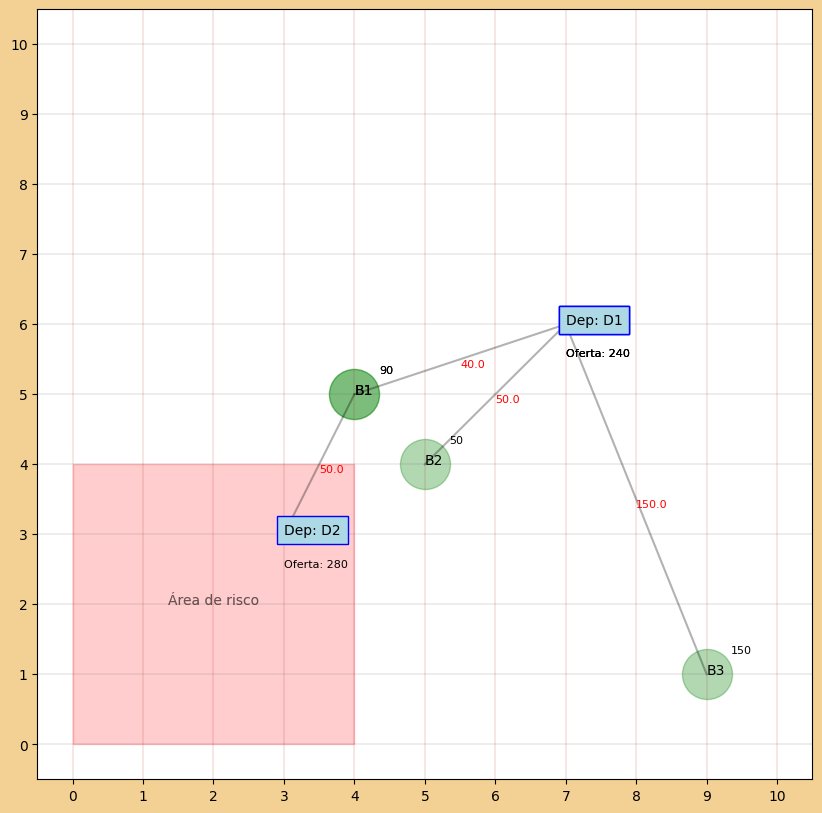

In [27]:
fig, ax = plt.subplots(figsize=(linhas,linhas))
# ax.set_facecolor('#F8F5F0')
fig.patch.set_facecolor("#F3D093")

for r in range(linhas + 1):
    
    ax.axhline(r, color="#5E5C5C", linewidth=0.15)
for c in range(colunas + 1):
    
    ax.axvline(c, color="#B11717", linewidth=0.15)
for nome_dep, info_d in informacoes_dep.items():
    for nome_bairro, info_b in informacoes_bairros.items():
        if model.x[nome_dep, nome_bairro].value > 0.05:

            # a posição [0] é a linha do (linha,coluna)
            # mas no grafico ela vira coluna, pois seria o X do grafico, entao tem q inverter

            # linha entre dois pontos
            ax.plot([info_d['pos'][1], info_b['pos'][1]], [info_d['pos'][0], info_b['pos'][0]], 'k-', alpha=0.3)
            meio_linha_x = (info_d['pos'][1] + info_b['pos'][1]) / 2
            meio_linha_y = (info_d['pos'][0] + info_b['pos'][0]) / 2
            ax.text(meio_linha_x, meio_linha_y, f"{model.x[nome_dep, nome_bairro].value:.1f}", fontsize=8, ha='left', va='top', color='red')

            # Plot do deposito
            # ax.scatter(info_d['pos'][0], info_d['pos'][1], color='blue', s=1300,alpha=0.3)
            ax.text(info_d['pos'][1], info_d['pos'][0], f"Dep: {nome_dep}", fontsize=10,bbox=dict(boxstyle="square,pad=0.5", fc="lightblue", ec="blue"))
            ax.text(info_d['pos'][1], info_d['pos'][0]-0.35, f"Oferta: {info_d['oferta']}", color='black', fontsize=8, ha='left', va='top',)
            
            # plot do bairro
            ax.scatter(info_b['pos'][1], info_b['pos'][0], color='green', s=1300,alpha=0.3)
            ax.text(info_b['pos'][1], info_b['pos'][0], nome_bairro, fontsize=10)
            ax.text(info_b['pos'][1]+0.35, info_b['pos'][0]+0.35, info_b['demanda'], color='black', fontsize=8, ha='left', va='center')
            

            #plot area de risco
            area_risco = mpatches.Rectangle((0,0),zona_risco[1],zona_risco[1],alpha=0.05, color='red')
            ax.add_patch(area_risco)
            ax.text(zx_max/2,zy_max/2,"Área de risco", alpha=0.2, ha='center')

            
plt.xticks(np.arange(0, linhas+1, 1))
plt.yticks(np.arange(0, linhas+1, 1))

plt.show()